# Employee Productivity & Burnout Risk Analyzer
### IBM HR Analytics Dataset

**Goal:** Predict employee burnout risk level (Low / Medium / High) using domain-driven feature engineering, K-Means clustering, and multiple ML + ANN models.

**What makes this unique:** The target variable `BurnoutRisk` does not exist in the original dataset — it is engineered from 5 satisfaction-related columns using domain knowledge about workplace burnout.

**Dataset:** IBM HR Analytics — 1,470 employees, 35 features, zero missing values.

## Step 1 — Imports
All required libraries loaded at the start:
- `pandas`, `numpy` — data handling
- `matplotlib`, `seaborn` — visualizations
- `sklearn` — preprocessing, clustering, ML models, evaluation
- `tensorflow/keras` — ANN model

In [36]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, f1_score)
from sklearn.linear_model import LogisticRegression
import tensorflow as tf
from sklearn.preprocessing import StandardScaler


## Step 2 — Load Dataset
Load the IBM HR Analytics dataset and preview it.

**Dataset:** 1,470 employees x 35 features, zero missing values — created by IBM data scientists.

In [12]:
df=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print('Shape:', df.shape)
print()
print('Missing values:')
print(df.isnull().sum())
print()
print('Score distribution:')
df.head()

Shape: (1470, 35)

Missing values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
Years

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Step 3 — Dataset Info
Check data types of all columns. Identifies which are numerical (int64) and which are categorical (object) — important for deciding encoding strategy.

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

## Step 4 — Feature Engineering (Burnout Score)
The most unique step of this project.

We create `BurnoutScore` — a new column that does not exist in the original dataset — derived from 5 existing columns using domain knowledge:
- `OverTime` (weight x3) — single biggest burnout driver
- `WorkLifeBalance <= 2` (weight x2) — poor balance signals stress
- `JobSatisfaction <= 2` (weight x2) — low satisfaction drives burnout
- `EnvironmentSatisfaction <= 2` (weight x1) — supporting signal
- `JobInvolvement <= 2` (weight x1) — low involvement = disengagement

Max possible score = 9. Weights chosen so thresholds are clean and interpretable.

In [14]:
# Create BurnoutRisk score from existing columns
# This is domain-driven feature engineering —
# combining multiple satisfaction signals into one score

df['BurnoutScore'] = (
    (df['OverTime'] == 'Yes').astype(int) * 3 +        # overtime = biggest burnout signal
    (df['WorkLifeBalance'] <= 2).astype(int) * 2 +     # poor work life balance
    (df['JobSatisfaction'] <= 2).astype(int) * 2 +     # low job satisfaction
    (df['EnvironmentSatisfaction'] <= 2).astype(int) + # poor environment
    (df['JobInvolvement'] <= 2).astype(int)             # low involvement
)

## Step 5 — Convert Score to Risk Label
Convert the continuous BurnoutScore into 3 discrete risk levels using a custom function:
- Score 0-3 → **0 (Low Risk)**
- Score 4-6 → **1 (Medium Risk)**
- Score 7-9 → **2 (High Risk)**

This becomes our target variable `BurnoutRisk` for all classification models.

In [15]:
def convert(value):
    if(value <=3):
        return 0
    elif(value <=6):
        return 1
    else:
        return 2
df['BurnoutRisk']=df['BurnoutScore'].apply(convert)

## Step 6 — Check Class Distribution
Verify how many employees fall into each burnout category.

Expect heavy class imbalance — most employees are Low Risk, very few are High Risk. This guides our class_weight strategy during model training.

In [16]:
print('BurnoutScore distribution:')
print(df['BurnoutScore'].value_counts().sort_index())
print()
print('BurnoutRisk distribution:')
print(df['BurnoutRisk'].value_counts().sort_index())
print()
print('Labels: 0=Low Risk, 1=Medium Risk, 2=High Risk')

BurnoutScore distribution:
BurnoutScore
0    183
1    211
2    254
3    326
4    174
5    155
6    100
7     44
8     20
9      3
Name: count, dtype: int64

BurnoutRisk distribution:
BurnoutRisk
0    974
1    429
2     67
Name: count, dtype: int64

Labels: 0=Low Risk, 1=Medium Risk, 2=High Risk


## Step 7 — EDA Viz 1: Burnout Risk Distribution
Bar chart + pie chart showing the proportion of each risk level.

**Why:** Makes class imbalance visually clear — justifies why we use class_weight in all models.

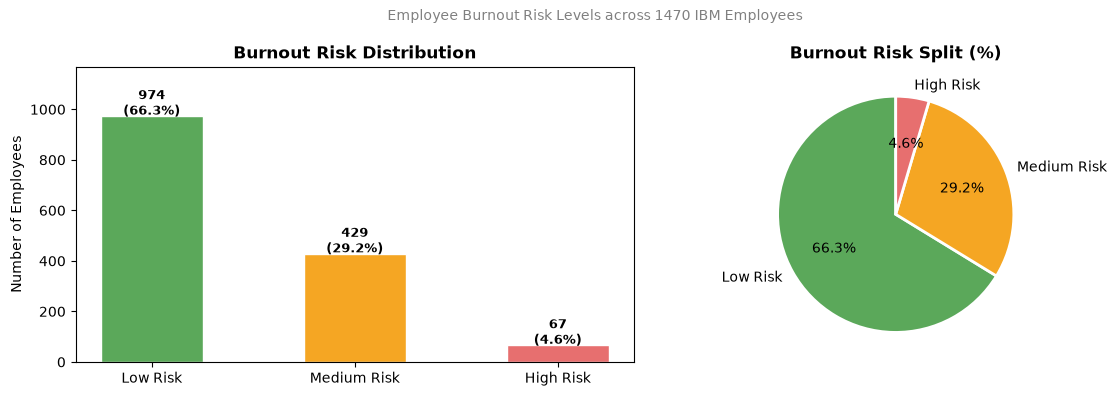

In [20]:
risk_counts = df['BurnoutRisk'].value_counts().sort_index()
labels = ['Low Risk', 'Medium Risk', 'High Risk']
colors = ['#5BA85A', '#F5A623', '#E76F6F']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(labels, risk_counts.values,
                   color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Burnout Risk Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Employees')
for bar, val in zip(bars, risk_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f'{val}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylim(0, max(risk_counts.values) * 1.2)

# Pie chart
axes[1].pie(risk_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Burnout Risk Split (%)', fontweight='bold')

plt.suptitle('Employee Burnout Risk Levels across 1470 IBM Employees',
             fontsize=10, color='gray')
plt.tight_layout()
plt.savefig('viz1_burnout_distribution.png', bbox_inches='tight')
plt.show()

## Step 8 — EDA Viz 2: Burnout Risk vs Attrition
Groupby BurnoutRisk and check the attrition rate at each level.

**Why:** Validates our feature engineering — if High Risk employees have significantly higher attrition, our BurnoutScore is meaningful and not arbitrary.

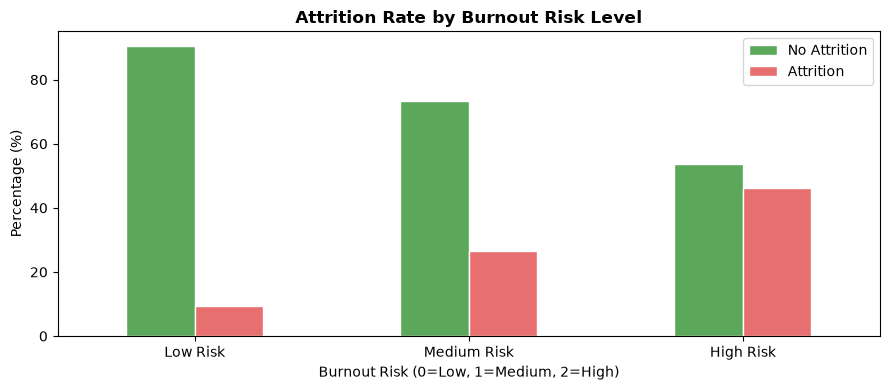

Attrition rate per burnout level:
  Low Risk: 9.4%
  Medium Risk: 26.6%
  High Risk: 46.3%


In [18]:
# Key insight — do high burnout employees actually leave?
burnout_attrition = df.groupby('BurnoutRisk')['Attrition']\
                      .value_counts(normalize=True)\
                      .unstack() * 100

fig, ax = plt.subplots(figsize=(9, 4))
burnout_attrition.plot(kind='bar', color=['#5BA85A', '#E76F6F'],
                       ax=ax, edgecolor='white', width=0.5)
ax.set_title('Attrition Rate by Burnout Risk Level', fontweight='bold')
ax.set_xlabel('Burnout Risk (0=Low, 1=Medium, 2=High)')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(['Low Risk', 'Medium Risk', 'High Risk'], rotation=0)
ax.legend(['No Attrition', 'Attrition'])
plt.tight_layout()
plt.savefig('viz2_burnout_vs_attrition.png', bbox_inches='tight')
plt.show()

# Print attrition rate per risk level
print('Attrition rate per burnout level:')
for level, label in zip([0,1,2], ['Low','Medium','High']):
    rate = df[df['BurnoutRisk']==level]['Attrition']\
             .value_counts(normalize=True).get('Yes', 0) * 100
    print(f'  {label} Risk: {rate:.1f}%')

## Step 9 — EDA Viz 3: Department-wise Burnout
Average burnout score per department using groupby.

**Why:** Business insight — tells HR which departments need immediate intervention. Makes the project actionable beyond just accuracy scores.

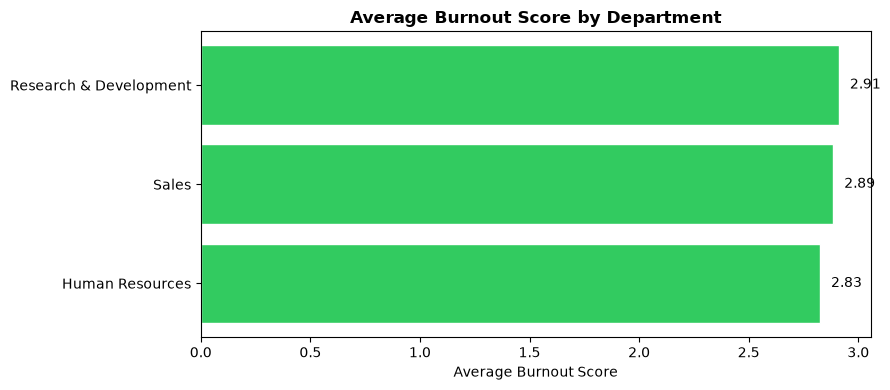

In [22]:
dept_burnout = df.groupby('Department')['BurnoutScore'].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(dept_burnout.index, dept_burnout.values,
               color="#32CB60", edgecolor='white')
ax.set_title('Average Burnout Score by Department', fontweight='bold')
ax.set_xlabel('Average Burnout Score')
for bar, val in zip(bars, dept_burnout.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('viz3_dept_burnout.png', bbox_inches='tight')
plt.show()

## Step 10 — EDA Viz 4: Income vs Satisfaction Heatmap
Pivot table of average MonthlyIncome by WorkLifeBalance (rows) and JobSatisfaction (columns), visualised as a heatmap.

**Why:** Reveals whether low-paid employees are also the least satisfied — a common workplace burnout pattern worth validating.

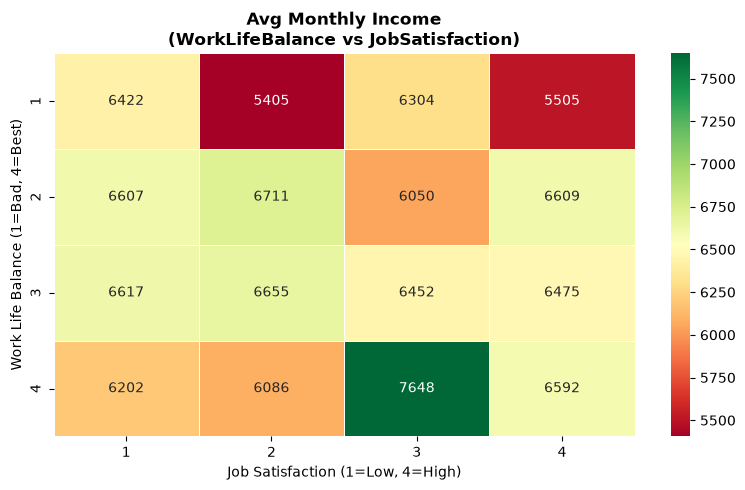

In [23]:
# Average monthly income per JobSatisfaction and WorkLifeBalance
pivot = df.pivot_table(values='MonthlyIncome',
                        index='WorkLifeBalance',
                        columns='JobSatisfaction',
                        aggfunc='mean')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn',
            ax=ax, linewidths=0.5)
ax.set_title('Avg Monthly Income\n(WorkLifeBalance vs JobSatisfaction)',
             fontweight='bold')
ax.set_xlabel('Job Satisfaction (1=Low, 4=High)')
ax.set_ylabel('Work Life Balance (1=Bad, 4=Best)')
plt.tight_layout()
plt.savefig('viz4_income_satisfaction_heatmap.png', bbox_inches='tight')
plt.show()

## Step 11 — EDA Viz 5: Overtime vs Burnout
Compare average burnout score between OverTime=Yes and OverTime=No groups.

**Why:** OverTime has the highest weight (x3) in our burnout formula — this chart visually validates that assumption before modelling.

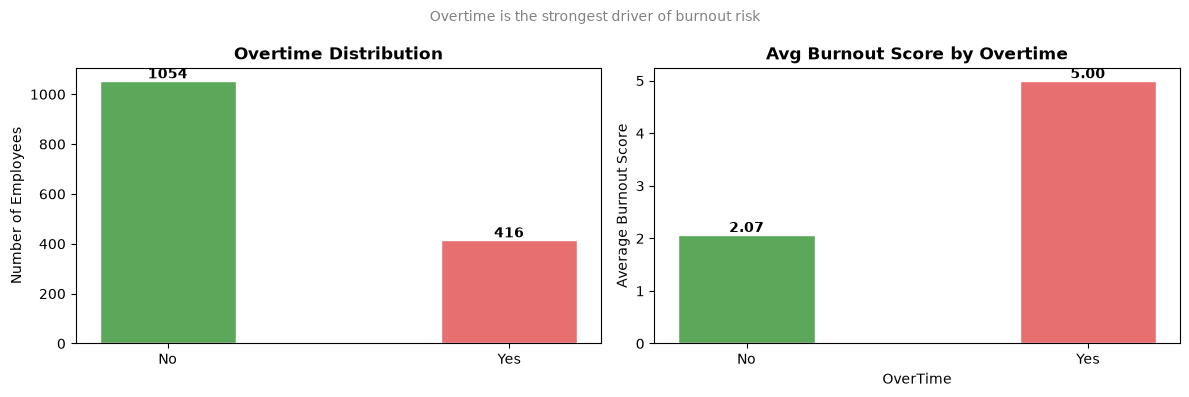

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overtime distribution
ot_counts = df['OverTime'].value_counts()
axes[0].bar(ot_counts.index, ot_counts.values,
            color=['#5BA85A', '#E76F6F'], edgecolor='white', width=0.4)
axes[0].set_title('Overtime Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Employees')
for i, (idx, val) in enumerate(ot_counts.items()):
    axes[0].text(i, val + 10, f'{val}', ha='center', fontweight='bold')

# Average BurnoutScore per OverTime group using groupby
ot_burnout = df.groupby('OverTime')['BurnoutScore'].mean()
axes[1].bar(ot_burnout.index, ot_burnout.values,
            color=['#5BA85A', '#E76F6F'], edgecolor='white', width=0.4)
axes[1].set_title('Avg Burnout Score by Overtime', fontweight='bold')
axes[1].set_xlabel('OverTime')
axes[1].set_ylabel('Average Burnout Score')
for i, (idx, val) in enumerate(ot_burnout.items()):
    axes[1].text(i, val + 0.05, f'{val:.2f}',
                 ha='center', fontweight='bold')

plt.suptitle('Overtime is the strongest driver of burnout risk',
             fontsize=10, color='gray')
plt.tight_layout()
plt.savefig('viz5_overtime_burnout.png', bbox_inches='tight')
plt.show()

## Step 12 — Preprocessing Part 1: Drop Useless Columns
Remove 4 columns that carry zero predictive information:
- `EmployeeCount` — value is 1 for all 1470 rows
- `Over18` — value is Y for all 1470 rows
- `StandardHours` — value is 80 for all 1470 rows
- `EmployeeNumber` — serial ID like a roll number

Also drop `BurnoutScore` — we only keep `BurnoutRisk` as the final target.

In [26]:
df_model = df.copy()

# Drop useless columns — same value for every row
df_model.drop(['EmployeeCount', 'Over18', 'StandardHours',
               'EmployeeNumber'], axis=1, inplace=True)

# Drop BurnoutScore — we keep only BurnoutRisk as target
df_model.drop('BurnoutScore', axis=1, inplace=True)

## Step 13 — Preprocessing Part 2: Label Encoding
Convert all categorical (string) columns to integers using LabelEncoder.

ML models cannot work with strings — every column must be numerical. LabelEncoder assigns a unique integer to each category value.

In [34]:
le = LabelEncoder()
str_cols = df_model.select_dtypes(include=['object']).columns
for col in str_cols:
    df_model[col] = le.fit_transform(df_model[col])
print('Shape after preprocessing:', df_model.shape)
print('Any nulls:', df_model.isnull().sum().sum())
print()
print('BurnoutRisk value counts:')
print(df_model['BurnoutRisk'].value_counts().sort_index())

Shape after preprocessing: (1470, 32)
Any nulls: 0

BurnoutRisk value counts:
BurnoutRisk
0    974
1    429
2     67
Name: count, dtype: int64


## Step 14 — Preview Preprocessed Data
Quick visual check of the final cleaned dataframe — all columns should now be numerical with no strings remaining.

In [53]:
df_model

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BurnoutRisk,Cluster
0,41,1,2,1102,2,1,2,1,2,0,...,0,8,0,1,6,4,0,5,1,1
1,49,0,1,279,1,8,1,1,3,1,...,1,10,3,3,10,7,1,7,0,0
2,37,1,2,1373,1,2,2,4,4,1,...,0,7,3,3,0,0,0,0,1,1
3,33,0,1,1392,1,3,4,1,4,0,...,0,8,3,3,8,7,3,0,0,1
4,27,0,2,591,1,2,1,3,1,1,...,1,6,3,3,2,2,2,2,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,1,884,1,23,2,3,3,1,...,1,17,3,3,5,2,0,3,0,2
1466,39,0,2,613,1,6,1,3,4,1,...,1,9,5,3,7,7,1,7,0,0
1467,27,0,2,155,1,4,3,1,2,1,...,1,6,0,3,6,2,0,3,1,1
1468,49,0,1,1023,2,2,3,3,4,1,...,0,17,3,2,9,6,0,8,1,0


## Step 15 — Prepare Features for Clustering
Select only the 5 burnout-related features for K-Means clustering:
`OverTime`, `WorkLifeBalance`, `JobSatisfaction`, `EnvironmentSatisfaction`, `JobInvolvement`

Scale with StandardScaler before clustering — K-Means is distance-based, so features with larger value ranges would unfairly dominate without scaling.

In [38]:
cluster_features = ['OverTime', 'WorkLifeBalance', 'JobSatisfaction',
                    'EnvironmentSatisfaction', 'JobInvolvement']

scaler_cluster = StandardScaler()
cluster_scaled = scaler_cluster.fit_transform(df_model[cluster_features])


## Step 16 — Elbow Method
Run K-Means for K=1 to 9, recording WCSS (Within Cluster Sum of Squares) at each step.

WCSS measures how tightly packed the clusters are — lower is better. We plot this to find the elbow point where adding more clusters gives diminishing returns.

In [ ]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,10):
    knn=KMeans(n_clusters=i,init='k-means++',random_state=42)
    knn.fit(cluster_scaled)
    wcss.append(knn.inertia_)


## Step 17 — Plot Elbow Curve
Plot WCSS vs K to visually identify the optimal number of clusters.

**Result:** Clear elbow at K=4 — four distinct employee segments exist in this burnout-feature space.

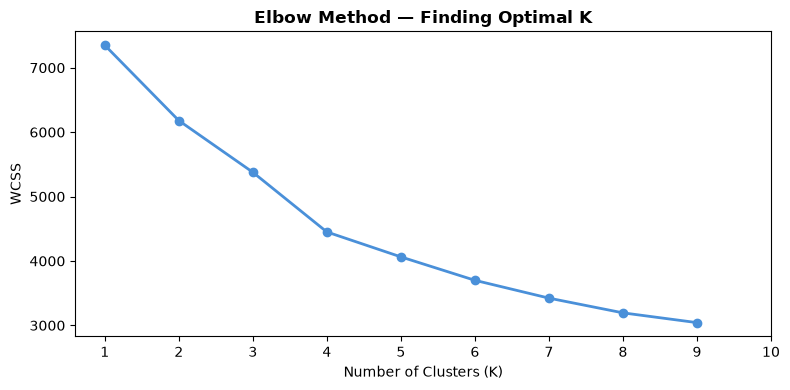

In [43]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 10), wcss, marker='o', color='#4A90D9',
         linewidth=2, markersize=6)
plt.title('Elbow Method — Finding Optimal K', fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.savefig('viz6_elbow.png', bbox_inches='tight')
plt.show()

## Step 18 — Apply K-Means with K=4
Fit final K-Means model with 4 clusters using k-means++ initialisation for better convergence.

`kmeans.labels_` gives cluster assignment (0-3) for each employee. Added back to both df and df_model for analysis.

In [47]:
kmeans=KMeans(n_clusters=4,init='k-means++',random_state=42)
kmeans.fit(X=cluster_scaled)
y_kmeans=kmeans.labels_
df_model['Cluster'] = y_kmeans
df['Cluster'] = y_kmeans

## Step 19 — Analyze Clusters
Inspect each cluster: size, average burnout score, and attrition rate.

**Key finding:** Cluster 1 (avg burnout 5.00) has 30.5% attrition — over 4x higher than Cluster 2 (7.1%). This is the high-risk employee segment HR should prioritise for retention.

In [51]:
print('Cluster sizes:')
print(df['Cluster'].value_counts().sort_index())
print()
print('Avg Burnout Score per Cluster:')
print(df.groupby('Cluster')['BurnoutScore'].mean().round(2).sort_index())
print()
print('Attrition rate per Cluster:')
attrition_rate = df.groupby('Cluster')['Attrition']\
                   .value_counts(normalize=True)\
                   .unstack() * 100
print(attrition_rate['Yes'].round(1))

Cluster sizes:
Cluster
0    383
1    416
2    368
3    303
Name: count, dtype: int64

Avg Burnout Score per Cluster:
Cluster
0    3.20
1    5.00
2    0.84
3    2.14
Name: BurnoutScore, dtype: float64

Attrition rate per Cluster:
Cluster
0    12.8
1    30.5
2     7.1
3    11.6
Name: Yes, dtype: float64


## Step 20 — Cluster Visualization
Two charts:
1. **Scatter plot** — JobSatisfaction vs WorkLifeBalance colored by cluster — shows how segments separate in satisfaction space
2. **Bar chart** — Average burnout score per cluster — visually confirms Cluster 1 as the high-burnout group

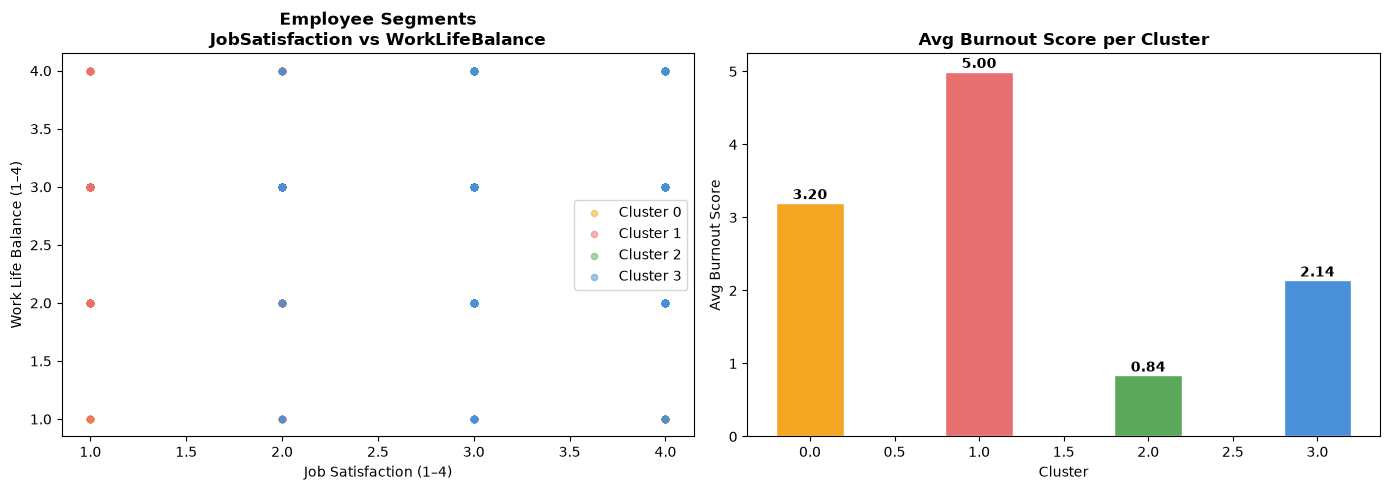

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_c = ['#F5A623', '#E76F6F', '#5BA85A', '#4A90D9']

# Scatter — JobSatisfaction vs WorkLifeBalance colored by cluster
for c in range(4):
    mask = df['Cluster'] == c
    axes[0].scatter(df[mask]['JobSatisfaction'],
                    df[mask]['WorkLifeBalance'],
                    c=colors_c[c], label=f'Cluster {c}',
                    alpha=0.5, s=20)
axes[0].set_title('Employee Segments\nJobSatisfaction vs WorkLifeBalance',
                  fontweight='bold')
axes[0].set_xlabel('Job Satisfaction (1–4)')
axes[0].set_ylabel('Work Life Balance (1–4)')
axes[0].legend()

# Avg burnout score per cluster
burnout_per_cluster = df.groupby('Cluster')['BurnoutScore'].mean()
bars = axes[1].bar(burnout_per_cluster.index,
                   burnout_per_cluster.values,
                   color=colors_c, edgecolor='white', width=0.4)
axes[1].set_title('Avg Burnout Score per Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Avg Burnout Score')
for bar, val in zip(bars, burnout_per_cluster.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('viz7_clusters.png', bbox_inches='tight')
plt.show()

## Step 21 — Feature/Target Split + Train Test Split
Separate features (X) and target (y = BurnoutRisk), scale X with StandardScaler, then split 67/33 train/test.

`stratify=y` ensures the same class ratio is preserved in both train and test sets — essential for imbalanced classification.

In [ ]:
X=df_model.drop(['BurnoutRisk','Cluster'],axis=1)
y=df['BurnoutRisk']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.33, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print()
print('Class distribution in train:')
print((y_train).value_counts().sort_index())


Train: 984 | Test: 486

Class distribution in train:
BurnoutRisk
0    652
1    287
2     45
Name: count, dtype: int64


## Step 22 — Define Class Weights
Manually assign higher importance to minority classes to counter imbalance:
- Class 0 (Low Risk, majority) — weight 2.0
- Class 1 (Medium Risk) — weight 3.0
- Class 2 (High Risk, minority) — weight 5.0

Higher weight = model is penalised more for misclassifying that class during training.

In [65]:
class_weights={0:2.0,1:3,2:5}

## Step 23 — ANN Imports
Import Sequential model, Dense and Dropout layers, and EarlyStopping callback from Keras.

In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping


## Step 24 — Build + Train ANN
**Architecture:**
- Hidden Layer 1: 128 neurons, ReLU
- Dropout(0.3) — randomly disables 30% of neurons to prevent overfitting
- Hidden Layer 2: 64 neurons, ReLU
- Dropout(0.3) — second regularisation layer
- Output: 3 neurons, **Softmax** — outputs probability for each risk class

**Key differences from binary classification:**
- `softmax` instead of `sigmoid` — 3 class probabilities that sum to 1
- `sparse_categorical_crossentropy` — correct loss for integer multiclass labels (0, 1, 2)
- EarlyStopping with patience=5 — stops when val_loss stops improving, restores best weights

In [66]:
ann=Sequential([
    Dense(units=128,activation='relu',input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(units=64,activation='relu'),
    Dropout(0.3),
    Dense(units=3,activation='softmax'),
])
ann.compile(optimizer='adam',metrics=['accuracy'],loss='sparse_categorical_crossentropy')
ann.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1)

history = ann.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,547 (49.01 KB)

 Trainable params: 12,547 (49.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5322 - loss: 2.5454 - val_accuracy: 0.6465 - val_loss: 0.7605
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7186 - loss: 1.8816 - val_accuracy: 0.6768 - val_loss: 0.6712
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7944 - loss: 1.6040 - val_accuracy: 0.7273 - val_loss: 0.5993
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8079 - loss: 1.4064 - val_accuracy: 0.7778 - val_loss: 0.5575
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8226 - loss: 1.2142 - val_accuracy: 0.7576 - val_loss: 0.5232
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8554 - loss: 1.0584 - val_accuracy: 0.7879 - val_loss: 0.5106
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8531 - loss: 0.9992 - val_accuracy: 0.7778 - val_loss: 0.4891
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8712 - loss: 0.9192 - val_accuracy: 0.7879 - val_loss

## Step 25 — ANN Prediction + Evaluation
`np.argmax()` picks the class with highest softmax probability as the final prediction.

Evaluate with accuracy and full classification report — check F1 score per class, especially High Risk (minority class).

In [67]:
y_pred_prob = ann.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print('=== ANN Results ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred,
      target_names=['Low Risk', 'Medium Risk', 'High Risk']))

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== ANN Results ===
Accuracy: 0.8498

              precision    recall  f1-score   support

    Low Risk       0.91      0.93      0.92       322
 Medium Risk       0.73      0.76      0.75       142
   High Risk       0.60      0.27      0.38        22

    accuracy                           0.85       486
   macro avg       0.75      0.65      0.68       486
weighted avg       0.84      0.85      0.84       486



## Step 26 — ML Model Imports
Import Logistic Regression, SVC, and Random Forest for comparison against the ANN.

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


## Step 27 — Define ML Models
- `LogisticRegression` — linear classifier, strong on small datasets, handles multiclass automatically
- `RandomForestClassifier` — 100 decision trees with entropy criterion, captures non-linear patterns

Both handle 3-class output automatically with no extra configuration.

In [76]:
log_reg=LogisticRegression()

rfc=RandomForestClassifier(n_estimators=100,random_state=42,criterion='entropy')

## Step 28 — Train ML Models
Fit both Logistic Regression and Random Forest on the training data.

In [78]:
log_reg.fit(X_train,y_train)
rfc.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap boot

## Step 29 — Logistic Regression Evaluation
**Result: 87.4% accuracy**

Best High Risk F1 (0.56) among all models — shows Logistic Regression performs strongly on small datasets where ANN may overfit.

In [73]:


# Logistic Regression

y_pred_lr = log_reg.predict(X_test)

print('=== Logistic Regression ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print()
print(classification_report(y_test, y_pred_lr,
      target_names=['Low Risk', 'Medium Risk', 'High Risk']))

=== Logistic Regression ===
Accuracy: 0.8745

              precision    recall  f1-score   support

    Low Risk       0.92      0.94      0.93       322
 Medium Risk       0.79      0.78      0.78       142
   High Risk       0.71      0.45      0.56        22

    accuracy                           0.87       486
   macro avg       0.81      0.73      0.76       486
weighted avg       0.87      0.87      0.87       486



## Step 30 — SVC Evaluation
SVC with RBF kernel. `class_weight` passed to handle class imbalance — without it SVC predicts 0 High Risk employees.

**Result: 86.6% accuracy**

In [80]:
svc = SVC(kernel='rbf', random_state=42,class_weight=class_weights)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

print('=== SVC ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}')
print()
print(classification_report(y_test, y_pred_svc,
      target_names=['Low Risk', 'Medium Risk', 'High Risk']))

=== SVC ===
Accuracy: 0.8663

              precision    recall  f1-score   support

    Low Risk       0.92      0.94      0.93       322
 Medium Risk       0.76      0.79      0.78       142
   High Risk       0.70      0.32      0.44        22

    accuracy                           0.87       486
   macro avg       0.79      0.68      0.71       486
weighted avg       0.86      0.87      0.86       486



## Step 31 — Random Forest Evaluation
**Result: 93.0% accuracy — best overall**

However High Risk recall is low (0.23) — it correctly identifies only a few High Risk employees despite 100% precision. Classic precision vs recall tradeoff on a minority class with limited training samples.

In [81]:
y_pred_rfc = rfc.predict(X_test)

print('=== Random Forest Classifier ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rfc):.4f}')
print()
print(classification_report(y_test, y_pred_rfc,
      target_names=['Low Risk', 'Medium Risk', 'High Risk']))

=== Random Forest Classifier ===
Accuracy: 0.9300

              precision    recall  f1-score   support

    Low Risk       0.96      0.99      0.97       322
 Medium Risk       0.87      0.89      0.88       142
   High Risk       1.00      0.23      0.37        22

    accuracy                           0.93       486
   macro avg       0.94      0.71      0.74       486
weighted avg       0.93      0.93      0.92       486

